Run this code in "napari" environment! 

In [1]:
import sys
sys.path.append('../src')
import os
import mrcfile
import numpy as np
from pinn.cryoet_io import open_raw_data
import jax.numpy as jnp

In [2]:
raw_data_path = "../data/VLP/VB_YL1_HIV_153E_WITO_MAT_24dec14a_TS62.mrc"
# mask_path = "../data/VLP/74_seg.mrc"

In [3]:
raw_data = open_raw_data(raw_data_path)

Data shape: (300, 1022, 1440)
Voxel size (angstroms): (0.0, 0.0, 0.0)
Map origin: (0.0, 0.0, 0.0)
Pixel spacing: (0.0, 0.0, 0.0)
Minimum and maximum density: 0.0 0.09825213
Mean density: 0.01907931
Number of columns, rows, and sections: 1440 1022 300
Data mode: 2
Cell dimensions (angstroms): (0.0, 0.0, 0.0)
Cell angles: (90.0, 90.0, 90.0)


In [4]:
with mrcfile.open(mask_path, permissive=True) as mrc_mask:
    data_mask = mrc_mask.data
    # Access header information
    print("Data shape:", mrc_mask.data.shape)  # Dimensions of the data
    print("Voxel size (angstroms):", mrc_mask.voxel_size)  # Voxel size if available
    print("Map origin:", mrc_mask.header.origin)  # Origin of the map
    print("Pixel spacing:", mrc_mask.voxel_size)  # Pixel spacing for each axis
    print("Minimum and maximum density:", mrc_mask.header.dmin, mrc_mask.header.dmax)
    print("Mean density:", mrc_mask.header.dmean)

    # Other specific header fields
    print("Number of columns, rows, and sections:", mrc_mask.header.nx, mrc_mask.header.ny, mrc_mask.header.nz)
    print("Data mode:", mrc_mask.header.mode)  # Data type (e.g., byte, float)
    print("Cell dimensions (angstroms):", mrc_mask.header.cella)  # Cell dimensions
    print("Cell angles:", mrc_mask.header.cellb)  # Cell angles

NameError: name 'mask_path' is not defined

In [3]:
# function that visualizes mrc data in napari
import napari

def napari_view(data, mask):
    viewer = napari.Viewer()
    viewer.add_image(data, name='tomogram', colormap='gray', blending='additive')
    if mask is not None:
        viewer.add_image(mask, name='mask', colormap='red', blending='additive', opacity=0.5)
    napari.run()

In [6]:
napari_view(raw_data, None)

In [5]:
# Crop data

import skimage.measure
import numpy as np
from skimage.transform import resize

# Define crop range in z, y, x
z_start, z_end = 35, 207  
y_start, y_end = 340, 672  
x_start, x_end = 478, 851    

# Crop the cryo-ET data
cropped_data = raw_data[z_start:z_end, y_start:y_end, x_start:x_end]
# cropped_mask = data_mask[z_start:z_end, y_start:y_end, x_start:x_end]

In [6]:
print(cropped_data.shape)
# print(cropped_mask.shape)

(172, 332, 373)


In [9]:
napari_view(cropped_data, None)     # Membrane: ~-1

In [7]:
shape = "62"
data_dir = "VLP_Cropped"

In [8]:
# Save cropped data
cropped_data_path = f"../data/{data_dir}/{shape}.mrc"
# output_mask_path = f"../data/Jake_Cropped/{shape}_mask.mrc"

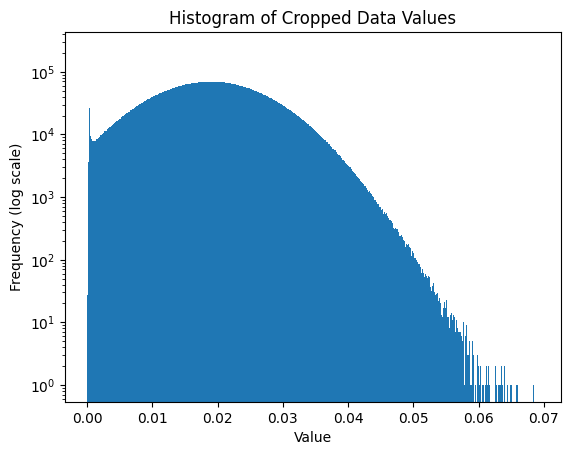

In [9]:
import matplotlib.pyplot as plt
plt.hist(cropped_data.ravel(), bins=1000)    # ravel() flattens the array
plt.yscale('log')
plt.title('Histogram of Cropped Data Values')
plt.xlabel('Value')
plt.ylabel('Frequency (log scale)')
plt.show()

In [14]:
# cropped_data_rm = np.where(cropped_data > -2.8, cropped_data, 0)
cropped_data_rm2 = np.where(cropped_data_rm > 1.5, 0, cropped_data_rm)
napari_view(cropped_data_rm2, None)

In [15]:
cropped_data = cropped_data_rm2

In [10]:
with mrcfile.new(cropped_data_path, overwrite=True) as mrc:
    mrc.set_data(cropped_data.astype(np.float32))

# with mrcfile.new(output_mask_path, overwrite=True) as mrc:
#     mrc.set_data(cropped_mask.astype(np.float32))

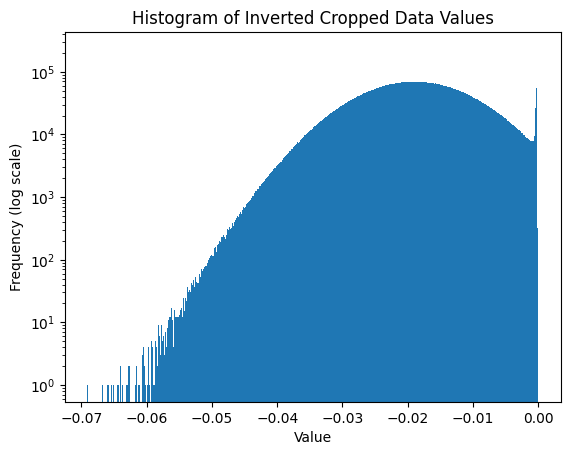

In [11]:
# Before normalization, check the distribution of values using mean and std and visualize with histogram
import matplotlib.pyplot as plt
import numpy as np
import mrcfile

# Reopen cropped data from mrc file
cropped_data_path = f"../data/{data_dir}/{shape}.mrc"
with mrcfile.open(cropped_data_path, permissive=True) as mrc:
    cropped_data = mrc.data

# Flipp the data by -1
cropped_data_inv = -cropped_data
# cropped_data = 1-cropped_data ###########

plt.hist(cropped_data_inv.ravel(), bins=1000)    # ravel() flattens the array
plt.yscale('log')
plt.title('Histogram of Inverted Cropped Data Values')
plt.xlabel('Value')
plt.ylabel('Frequency (log scale)')
plt.show()

In [17]:
napari_view(cropped_data_inv, None)

In [ ]:
import jax
import jax.numpy as jnp

# Set the range for normalization
norm_min, norm_max = 0.0, 1.0

# Normalize data so that the values are between 0 and 1
data_min = np.min(cropped_data_inv)
data_max = np.max(cropped_data_inv)

print("Data min:", data_min)
print("Data max:", data_max)

# You want membrane regions to be 1 and non-membrane regions to be 0
normalized_data = (cropped_data_inv - data_min) / (data_max - data_min)
normalized_data = normalized_data * (norm_max - norm_min) + norm_min
print("Normalized data min:", np.min(normalized_data))
print("Normalized data max:", np.max(normalized_data))
normalized_data = jnp.asarray(normalized_data, dtype=jnp.float32)

# Draw histogram of normalized data
plt.hist(np.array(normalized_data).ravel(), bins=1000)    # ravel() flattens the array
plt.yscale('log')
plt.title('Histogram of Normalized Data Values')
plt.xlabel('Value')
plt.ylabel('Frequency (log scale)')
plt.show()

Data min: -0.069126606
Data max: -0.0
Normalized data min: 0.0
Normalized data max: 1.0


In [ ]:
napari_view(normalized_data, None)

In [14]:
normalized_path = f"../data/{data_dir}/{shape}_normalized.mrc"

with mrcfile.new(normalized_path, overwrite=True) as mrc:
    mrc.set_data(normalized_data.astype(np.float32))

In [28]:
import mrcfile
import numpy as np

thre = 0.9

binary_path = f"../data/{data_dir}/{shape}_normalized_binary_{thre}.mrc"

with mrcfile.open(normalized_path, permissive=True) as mrc:
    norm_data = mrc.data
binary_data = np.where(norm_data > thre, 1, 0)

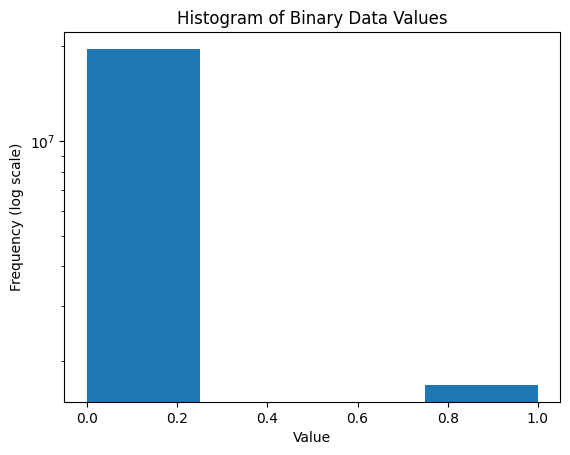

In [29]:
plt.hist(binary_data.ravel(), bins=4)    # ravel() flattens the array
plt.yscale('log')
plt.title('Histogram of Binary Data Values')
plt.xlabel('Value')
plt.ylabel('Frequency (log scale)')
plt.show()

In [33]:
napari_view(norm_data, None)

In [30]:
napari_view(binary_data, None)

In [31]:
with mrcfile.new(binary_path, overwrite=True) as mrc:
    mrc.set_data(binary_data.astype(np.float32))

# Kernels, Filters

### Ridge Operator

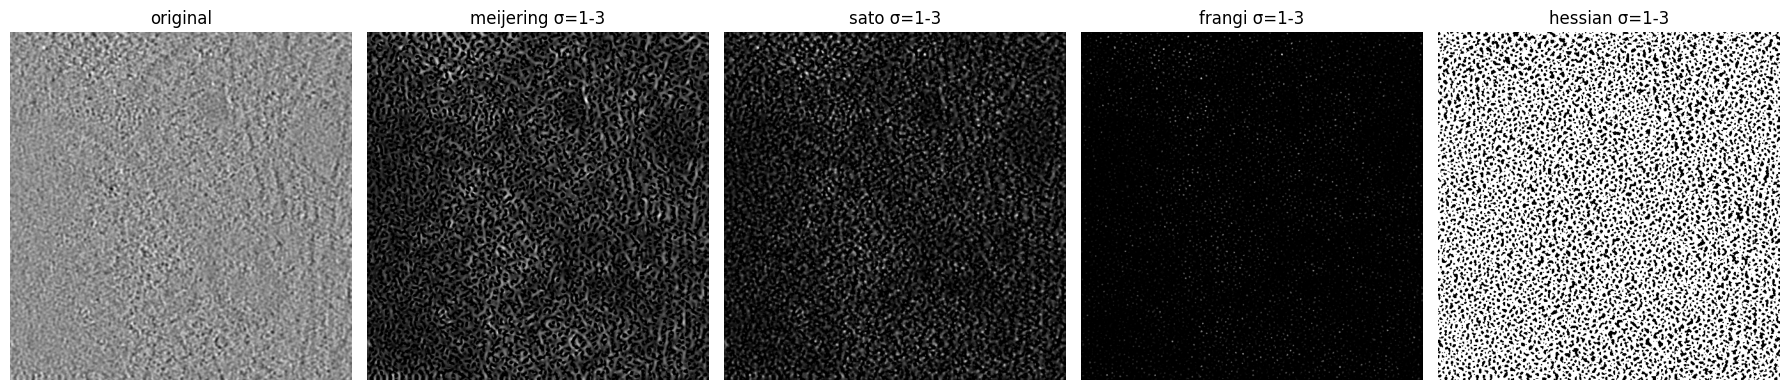

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import meijering, sato, frangi, hessian

# === Pick representative slice index ===
z_idx = norm_data.shape[0] // 2  # middle z-slice
cmap = plt.cm.gray

# === Apply multi-scale ridge filters (3D aware) ===
filters = [
    ("original", norm_data),
    ("meijering σ=1-3", meijering(norm_data, sigmas=range(1, 4), black_ridges=False)),
    ("sato σ=1-3", sato(norm_data, sigmas=range(1, 4), black_ridges=False)),
    ("frangi σ=1-3", frangi(norm_data, sigmas=range(1, 4), black_ridges=False)),
    ("hessian σ=1-3", hessian(norm_data, sigmas=range(1, 4), black_ridges=False)),
]

# === Plot: compare middle slice for each filter ===
fig, axes = plt.subplots(1, len(filters), figsize=(18, 4))
for ax, (title, vol) in zip(axes, filters):
    ax.imshow(vol[z_idx, :, :], cmap=cmap)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import napari
viewer = napari.Viewer()
viewer.add_image(norm_data, name='original')
viewer.add_image(frangi(norm_data, sigmas=range(1, 4)), name='frangi')
napari.run()

### Canny Edge Detector

In [20]:
import os
import numpy as np
import mrcfile
import matplotlib.pyplot as plt
from skimage.feature import canny
from scipy.ndimage import gaussian_filter


# ---------- 유틸: 2D Canny를 축별로 적용해 3D로 확장 ----------
def canny_along_axis(vol01: np.ndarray, sigma=1.0, axis=0,
                     low_threshold=None, high_threshold=None,
                     use_gaussian_prefilter=True, pre_sigma=0.0):
    """
    vol01: (Z,Y,X) in [0,1]
    axis: 0=Z-slices (ZYX에서 평면은 YX), 1=Y-slices (ZX 평면), 2=X-slices (ZY 평면)
    return: boolean volume same shape
    """
    assert vol01.ndim == 3
    V = vol01
    if use_gaussian_prefilter and pre_sigma > 0:
        V = gaussian_filter(V, sigma=pre_sigma)

    # 축을 앞으로 가져와서 맨 앞 차원을 슬라이스로 순회
    V_t = np.moveaxis(V, axis, 0)  # (S, H, W)
    out_t = np.zeros_like(V_t, dtype=bool)

    for k in range(V_t.shape[0]):
        out_t[k] = canny(
            V_t[k],
            sigma=sigma,
            low_threshold=low_threshold,
            high_threshold=high_threshold
        )

    # 원래 축 순서로 되돌리기
    out = np.moveaxis(out_t, 0, axis)
    return out

def canny_3d_by_orientations(vol01: np.ndarray, sigma=1.0,
                             low_threshold=None, high_threshold=None,
                             pre_sigma=0.0):
    """
    세 축(Z,Y,X)으로 각각 2D-Canny → OR 결합
    """
    ez = canny_along_axis(vol01, sigma=sigma, axis=0,
                          low_threshold=low_threshold, high_threshold=high_threshold,
                          use_gaussian_prefilter=True, pre_sigma=pre_sigma)
    ey = canny_along_axis(vol01, sigma=sigma, axis=1,
                          low_threshold=low_threshold, high_threshold=high_threshold,
                          use_gaussian_prefilter=True, pre_sigma=pre_sigma)
    ex = canny_along_axis(vol01, sigma=sigma, axis=2,
                          low_threshold=low_threshold, high_threshold=high_threshold,
                          use_gaussian_prefilter=True, pre_sigma=pre_sigma)
    e_or = ez | ey | ex
    return ez, ey, ex, e_or


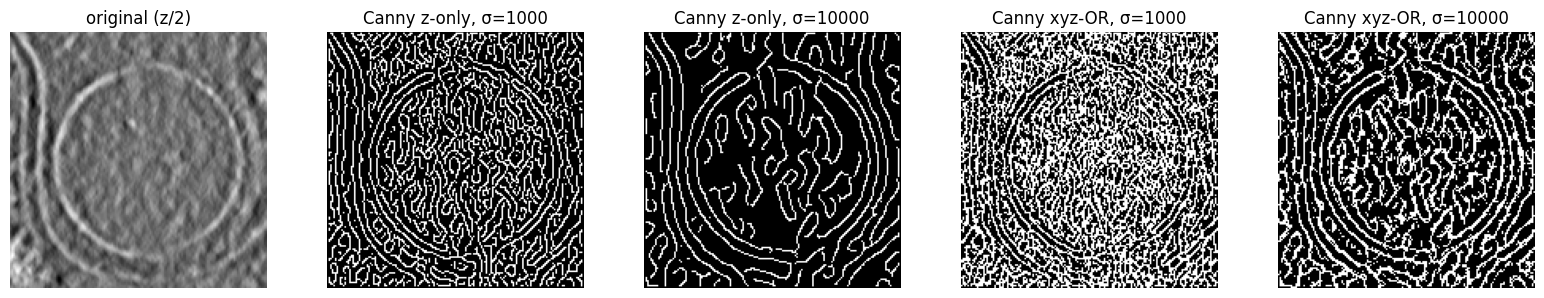

In [50]:
# [0,1] 정규화 (안정성을 위해)
vmin, vmax = float(filtered_data.min()), float(filtered_data.max())
if vmax > vmin:
    vol01 = (norm_data - vmin) / (vmax - vmin)
else:
    vol01 = np.zeros_like(norm_data, dtype=np.float32)


# ---------- 파라미터 ----------
# Canny 자체 sigma (영상의 가우시안 블러 표준편차, voxel 단위)
sigma_list = [1000.0, 10000.0]
# 선택: 고주파 노이즈가 많으면 Canny 전 별도 3D 블러를 살짝
pre_sigma = 0.0  # 예: 0.5 ~ 1.0 주면 안정적일 수 있음
low_th, high_th = None, None  # (None이면 자동 히스테리시스)

# ---------- 계산: z-축 전용과 3방향 OR 둘 다 ----------
# 결과 변수들 (요청대로 각각 저장)
edges_z_sigma1   = canny_along_axis(vol01, sigma=1.0, axis=0,
                                    low_threshold=low_th, high_threshold=high_th,
                                    use_gaussian_prefilter=True, pre_sigma=pre_sigma)
edges_z_sigma3   = canny_along_axis(vol01, sigma=3.0, axis=0,
                                    low_threshold=low_th, high_threshold=high_th,
                                    use_gaussian_prefilter=True, pre_sigma=pre_sigma)

ez1, ey1, ex1, edges_xyz_or_sigma1 = canny_3d_by_orientations(
    vol01, sigma=1.0, low_threshold=low_th, high_threshold=high_th, pre_sigma=pre_sigma
)
ez3, ey3, ex3, edges_xyz_or_sigma3 = canny_3d_by_orientations(
    vol01, sigma=3.0, low_threshold=low_th, high_threshold=high_th, pre_sigma=pre_sigma
)

# ---------- 미리보기: 중앙 z-슬라이스 ----------
z_mid = vol01.shape[0] // 2

fig, axes = plt.subplots(1, 5, figsize=(16, 3))
axes[0].imshow(vol01[z_mid], cmap='gray')
axes[0].set_title("original (z/2)")
axes[1].imshow(edges_z_sigma1[z_mid], cmap='gray')
axes[1].set_title("Canny z-only, σ=1000")
axes[2].imshow(edges_z_sigma3[z_mid], cmap='gray')
axes[2].set_title("Canny z-only, σ=10000")
axes[3].imshow(edges_xyz_or_sigma1[z_mid], cmap='gray')
axes[3].set_title("Canny xyz-OR, σ=1000")
axes[4].imshow(edges_xyz_or_sigma3[z_mid], cmap='gray')
axes[4].set_title("Canny xyz-OR, σ=10000")
for a in axes: a.axis('off')
plt.tight_layout()
plt.show()


In [51]:
try:
    import napari
    viewer = napari.Viewer()
    viewer.add_image(vol01, name="original", blending='additive', colormap='gray', contrast_limits=[0,1])
    viewer.add_labels(edges_z_sigma1.astype(np.uint8), name="edges_z σ=1")
    viewer.add_labels(edges_z_sigma3.astype(np.uint8), name="edges_z σ=3")
    viewer.add_labels(edges_xyz_or_sigma1.astype(np.uint8), name="edges_xyzOR σ=1")
    viewer.add_labels(edges_xyz_or_sigma3.astype(np.uint8), name="edges_xyzOR σ=3")
    napari.run()
except Exception as e:
    print("Napari failed to launch (headless or missing GUI):", repr(e))


In [61]:
viewer = napari.Viewer()
viewer.add_image(norm_data, name="original", blending='additive', colormap='gray', contrast_limits=[0,1])

<Image layer 'original' at 0x76327ef10350>

In [54]:
napari_view(vol01, None)

### Gaussian filter

In [35]:
from scipy.ndimage import gaussian_filter

def gaussian_filter_3d_nopad(volume, sigma=1.0, truncate=4.0):
    radius = int(round(truncate * sigma))
    blurred = gaussian_filter(volume, sigma=sigma, truncate=truncate, mode='reflect')
    return blurred[radius:-radius, radius:-radius, radius:-radius]

In [47]:
from scipy.ndimage import convolve

# Example usage:
kernel_size = 10  # Creates a 5x5x5 kernel
sigma = 3.0

filtered_data = gaussian_filter_3d_nopad(norm_data, sigma=sigma, truncate=4.0)

In [48]:
print(norm_data.shape)
print(filtered_data.shape)

(170, 162, 162)
(146, 138, 138)


In [49]:
napari_view(filtered_data, None)

In [59]:
print(norm_data.min())
print(norm_data.max())

0.0
1.0


In [ ]:
import os
import mrcfile
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

dir = "../data/Krios_Data"

flist = os.listdir(dir)
nfile = len(flist)

nrow = 4
ncol = int(np.ceil(nfile/nrow))

fig, axes = plt.subplots(nrow, ncol, figsize=(15, 10))
axes = axes.flatten()

for idx, file in enumerate(flist):
    filename = os.fsdecode(file)
    print(f"Opening {filename} ...")

    try:
        file_path = os.path.join(dir, filename)

        if filename.endswith(".mrc"):
            with mrcfile.open(file_path) as mrc:
                data = mrc.data.astype(jnp.float32)
        elif filename.endswith(".tif"):
            data = tifffile.imread(raw_data_path)
        else:
            print(f"Unexpected filename detected: {filename}, must end with either .mrc or .tif")

        ax = axes[idx]
        ax.hist(data.ravel(), bins=1000)
        ax.xlabel("Value")
        ax.yscale('log')
        ax.ylabel("Frequency")
        ax.title(filename)

    except:
        print("Error")
        continue

for idx in range(nfile, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

Opening kjc100-293T-315-luciferase-LNPs-25jul24a-TS65_denoised.mrc ...
Error
Opening kjc100-293T-315-luciferase-LNPs-25jul24a-TS70_denoised.mrc ...
Error
Opening kjc100-293T-315-luciferase-LNPs-25jul24a-TS15.mrc ...
Error
Opening kjc140-293T-F-PDL_DiI_315-luciferase-LNPs-10min-25sep02a-TS80.mrc ...
Error
Opening kjc100-293T-315-luciferase-LNPs-25jul24a-TS70.mrc ...


In [ ]:

imshow()